# Market Sizing Analysis

## Objective

This notebook estimates the South African online food delivery market using the
TAM (Total Addressable Market),
SAM (Serviceable Available Market), and
SOM (Serviceable Obtainable Market) framework.

The analysis uses synthetic customer data combined with publicly available demographic assumptions to estimate annual market revenue.

In [1]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Load the dataset
df = pd.read_csv('../data/cleaned_data.csv')
df.head()

,user_id,age,city,income_level,app_used,orders_per_month,avg_order_value
0,0,42,Pretoria,Low,Mr D,3,83
1,1,26,Durban,Medium,Uber Eats,9,149
2,2,30,Pretoria,High,Uber Eats,9,164
3,3,53,Cape Town,Low,Mr D,0,81
4,4,33,Durban,High,Mr D,15,198


In [3]:
# Each customer's annual spending
df["annual_spend"] = (
    df["orders_per_month"] *
    df["avg_order_value"] *
    12
)

df.head()

,user_id,age,city,income_level,app_used,orders_per_month,avg_order_value,annual_spend
0,0,42,Pretoria,Low,Mr D,3,83,2988
1,1,26,Durban,Medium,Uber Eats,9,149,16092
2,2,30,Pretoria,High,Uber Eats,9,164,17712
3,3,53,Cape Town,Low,Mr D,0,81,0
4,4,33,Durban,High,Mr D,15,198,35640


In [4]:
df.describe()

,user_id,age,orders_per_month,avg_order_value,annual_spend
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000
mean,999.500000,38.651500,6.720000,144.017500,14124.59400
std,577.494589,11.854126,5.080995,54.990328,14726.90015
min,0.000000,18.000000,0.000000,60.000000,0.00000
25%,499.750000,29.000000,3.000000,105.000000,3168.00000
50%,999.500000,38.000000,6.000000,134.000000,9504.00000
75%,1499.250000,49.000000,9.000000,169.000000,17892.00000
max,1999.000000,59.000000,20.000000,299.000000,69600.00000


In [5]:
avg_annual_spend = df["annual_spend"].mean()

print(avg_annual_spend)

14124.594


# Estimate TAM

With assumptions in the following:

1. Approximately South Africa population ≈ 65 million.
2. With 24 million adults.
3. 18 million smartphone users.
4. and Approximately 8 million people regularly use food delivery.

In [7]:
potential_customers = 8_000_000

tam = potential_customers * avg_annual_spend

print(f"TAM = R{tam:,.0f}")


TAM = R112,996,752,000


# Estimate SAM

narrowing down the market.

assumptions:

Only:

1. Urban residents
2. Smartphone owners
3. Internet users
4. Cities where delivery services operate

In [8]:
serviceable_customers = 3_500_000

sam = serviceable_customers * avg_annual_spend

print(f"SAM = R{sam:,.0f}")

SAM = R49,436,079,000


# Estimate SOM

estimating what a new company could realistically capture.


First-year market share:

In [9]:
market_share = 0.02

som = sam * market_share

print(f"SOM = R{som:,.0f}")

SOM = R988,721,580


In [10]:
#Summary Table
market = pd.DataFrame({
    "Market":["TAM","SAM","SOM"],
    "Customers":[
        potential_customers,
        serviceable_customers,
        serviceable_customers*market_share
    ],
    "Annual Revenue":[
        tam,
        sam,
        som
    ]
})

market

,Market,Customers,Annual Revenue
0,TAM,8000000.0,1.129968e+11
1,SAM,3500000.0,4.943608e+10
2,SOM,70000.0,9.887216e+08


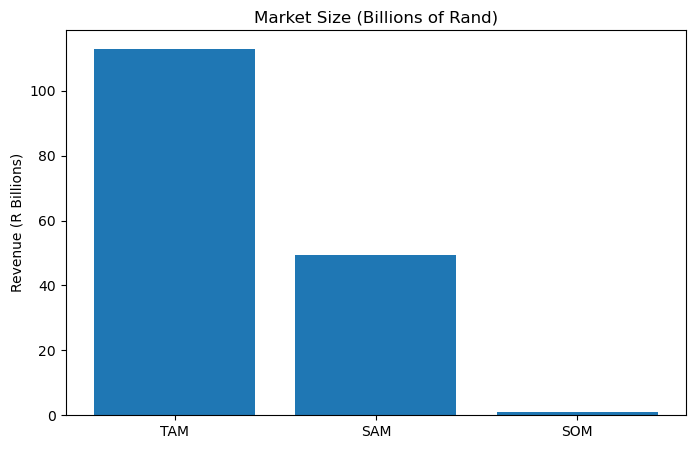

In [11]:
# Market Funnel Visualization
plt.figure(figsize=(8,5))

plt.bar(
    market["Market"],
    market["Annual Revenue"] / 1e9
)

plt.title("Market Size (Billions of Rand)")
plt.ylabel("Revenue (R Billions)")

plt.show()

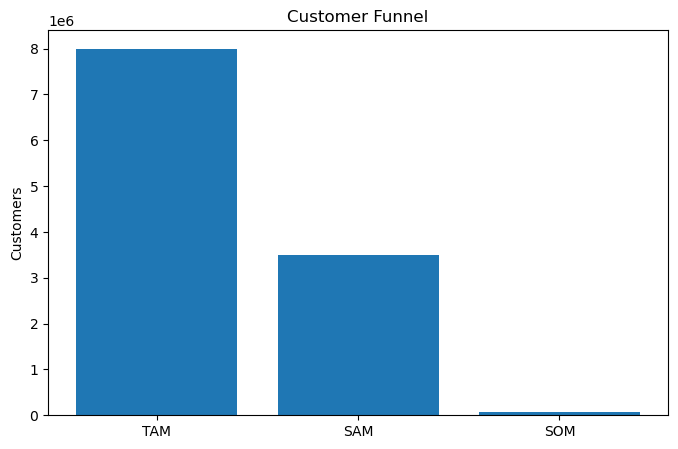

In [12]:
#Customer funnel visualization
plt.figure(figsize=(8,5))

plt.bar(
    market["Market"],
    market["Customers"]
)

plt.title("Customer Funnel")

plt.ylabel("Customers")

plt.show()

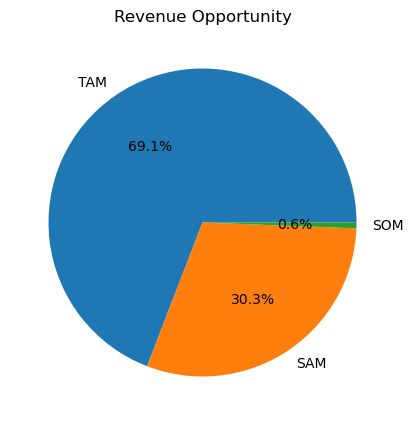

In [13]:
#Revenue Breakdown
plt.figure(figsize=(8,5))

plt.pie(
    market["Annual Revenue"],
    labels=market["Market"],
    autopct="%1.1f%%"
)

plt.title("Revenue Opportunity")

plt.show()

In [14]:
#export the market summary to a CSV file
market.to_csv("../data/market_summary.csv", index=False)